# Getting an overview
- loading the data files
- shape of tables
- columns

In [1]:
import pandas as pd

path = r"C:\Users\ThinkPad\Desktop\Mastermind\Inside_Airbnb_Berlin\Data\listings.csv"
listings = pd.read_csv(path)
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 14274 entries, 0 to 14273
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            14274 non-null  int64  
 1   listing_url                                   14274 non-null  str    
 2   scrape_id                                     14274 non-null  int64  
 3   last_scraped                                  14274 non-null  str    
 4   source                                        14274 non-null  str    
 5   name                                          14274 non-null  str    
 6   description                                   13712 non-null  str    
 7   neighborhood_overview                         6474 non-null   str    
 8   picture_url                                   14274 non-null  str    
 9   host_id                                       14274 non-null  int64  
 1

In [2]:
# getting the table headers as a text file
with open("../Data/listings_headers.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(listings.columns))

# Ideas what to plot from table headers
- the lower the number for **host_since** the higher the xx price?
- the lower the host_response_time the xxxxxx
- what does **host_is_superhost, host_verifications, host_has_profile_pic, host_identity_verified** acutally benefit the host?
- Spread of **minimum_minimum_nights, maximum_minimum_nights, minimum_maximum_nights, maximum_maximum_nights**
- Make correlation matrix for all numeric columns
- Via **avability_30, .._60, ..._90, ..._365**: How long before the acutal traval do people book? And when whas the data scapped? -> **calendar_last_scraped**
- Many recent reviews -> many recent bookings and vice versa for long ago reviews
- When did most new airbnbs enter the marked?
- revenue!
- how does instant bookable influence the avabililty?
- reviews per month
- big business behind the airbnb? **calculated_host_listings_count**
- What should be in the name or description to make it bookable




# Questions needed to be answered:
- How many nunique (and which) for **property_type**? -> 65
- How many nunique for **room_type**? -> 4

In [3]:

# getting the table headers & nunique vlaues as a text file
nu = listings.nunique()
with open("../Data/listing_headers_nunique.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(f"{col}: {count}" for col, count in nu.items()))

# Correlation matrix for all columns containing numbers

In [4]:
# only one dicimal as many numbers
# remove id, scrape_id, host_id, calendar_updated, as either meaningles or empty columns

import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
os.makedirs("../Data/SelmasPlots", exist_ok=True)

cols_to_drop = [
    "id", "scrape_id", "host_id", "calendar_updated",
    "host_total_listings_count", "host_listings_count",
    "latitude", "longitude",
    "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
    "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
    "number_of_reviews", "number_of_reviews_l30d", "number_of_reviews_ly",
    "review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness",
    "review_scores_checkin", "review_scores_communication",
    "review_scores_location", "review_scores_value",
    "bathrooms", "bedrooms", "beds",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms", "availability_30", "availability_60", "availability_90", "availability_eoy"
]

# Custom order: stays/size → availability → reviews → host/revenue
ordered_cols = [
    "accommodates", "minimum_nights", "maximum_nights",
    "availability_365",
    "number_of_reviews_ltm", "reviews_per_month",
    "estimated_occupancy_l365d", "estimated_revenue_l365d",
    "calculated_host_listings_count",
]

# Mask the diagonal (where value = 1.0)
mask = np.eye(len(corr), dtype=bool)

# Show only LOWER triangle (hides upper + diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr, annot=True, fmt=".1f", cmap="coolwarm", center=0,
    mask=mask, vmin=-0.5, vmax=0.9,
    cbar_kws={"label": "Correlation"}
)
plt.savefig("../Data/SelmasPlots/correlation_matrix_everynumberedcolumn.png", bbox_inches="tight", dpi=150)
plt.show()

NameError: name 'corr' is not defined

# Ideas from Claude

## Plot mapping (each topic = a different plot type):

* Map (boroughs by listing count / price) → Choropleth
* DONE: Commercial hosts → Pareto chart (Bar + Line overlaid ✓)
* DONE: Superhost rating → Violin plot (instead of boxplot — more sophisticated)
* DONE: Host tenure → Histogram with KDE line overlay
* CALENDAR: Prices throughout the year → Line chart + trendline / moving average
* CALENDAR: Weekdays → Ridge plot (stacked density curves)
* CALENDAR: Heatmap day × month → stays a heatmap
* Price ↔ Rating → Scatter with regression line (sns.regplot or lmplot) ✓
* >90 days violations → ECDF plot with vertical line at 90

## Where clustering makes sense:

DONE: K-Means on listings: features like price, accommodates, review_scores_rating, availability_365, calculated_host_listings_count → discover groups such as "cheap private rooms", "luxury apartments", "commercial tourist flats"
Visualization: PCA reduced to 2D + scatter colored by cluster, or plot directly on the map

## Sophisticated overlay plots:

Scatter + regression curve (price ↔ rating)
Bar + Line (Pareto: hosts × cumulative revenue %)
Map + cluster colors (listings as points, colored by cluster)
Histogram + KDE (host tenure)
Boxplot + strip plot (superhost vs. non-superhost, with individual points overlaid)

## Recommendation — diverse plot gallery:

Choropleth (map)
Pareto (bar + line)
Scatter + regression
Heatmap
Violin
Cluster scatter (PCA)
ECDF

= 7 different plot types, one clustering, one regression, two overlaid plot combinations. ✓

# Commercial host -> Pareto chart

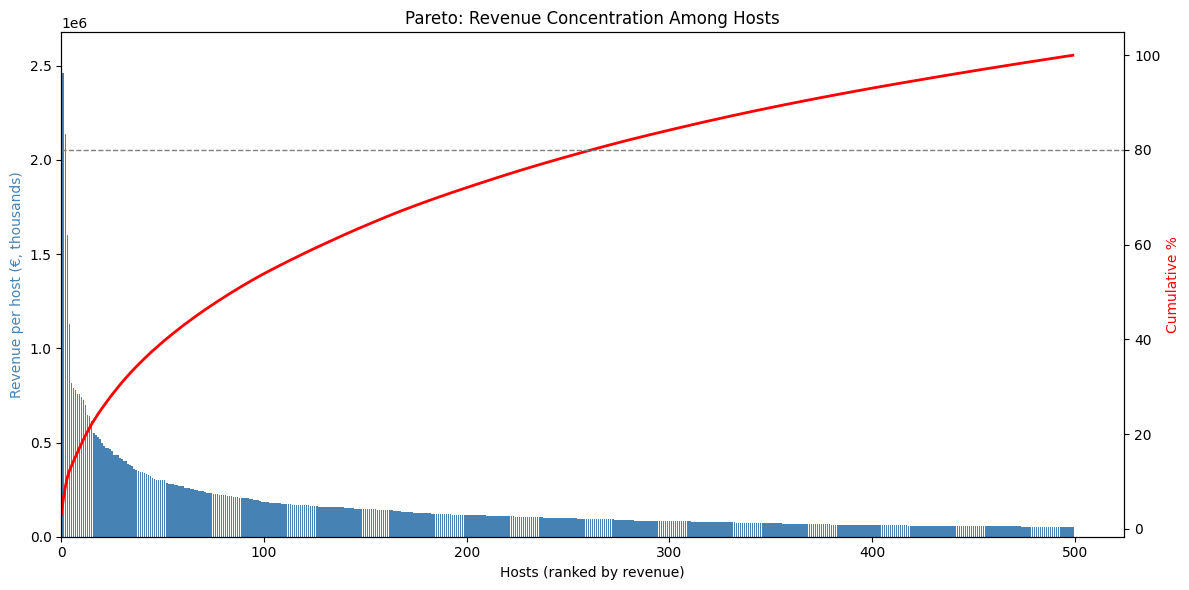

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("../Data/SelmasPlots", exist_ok=True)

# 1. Get revenue per host, sorted descending
host_revenue = (
    listings.groupby("host_id")["estimated_revenue_l365d"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(drop=True)
)


top_n = 500
host_revenue = host_revenue.iloc[:top_n]
cumulative_pct = cumulative_pct.iloc[:top_n]


# 2. Cumulative percentage
cumulative_pct = host_revenue.cumsum() / host_revenue.sum() * 100

# 3. Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(range(len(host_revenue)), host_revenue, color="steelblue")
ax1.set_xlabel("Hosts (ranked by revenue)")
ax1.set_ylabel("Revenue per host (€, thousands)", color="steelblue")
# ax1.set_yscale("log")  # log scale to see the long tail
ax1.set_xlim(left=0)

ax2 = ax1.twinx()
ax2.plot(range(len(cumulative_pct)), cumulative_pct, color="red", linewidth=2)
ax2.set_ylabel("Cumulative %", color="red")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)

plt.title("Pareto: Revenue Concentration Among Hosts")
plt.tight_layout()
plt.savefig("../Data/SelmasPlots/pareto_host_revenue.png", bbox_inches="tight", dpi=150)
plt.show()

 Ungefähr die Top 1.000 von ~9.500 Hosts (also nur ~10%) erwirtschaften 80% des gesamten Airbnb-Umsatzes in Berlin — das ist eine extreme Konzentration und ein klares Zeichen für einen stark kommerzialisierten Markt. Die restlichen 90% der Hosts teilen sich nur 20% des Umsatzes auf, was bedeutet, dass die meisten Vermieter eher Gelegenheits-Hosts sind, während eine kleine Gruppe von Profi-/Mehrfach-Vermietern den Markt dominiert.

#  Superhost rating → Violin plot


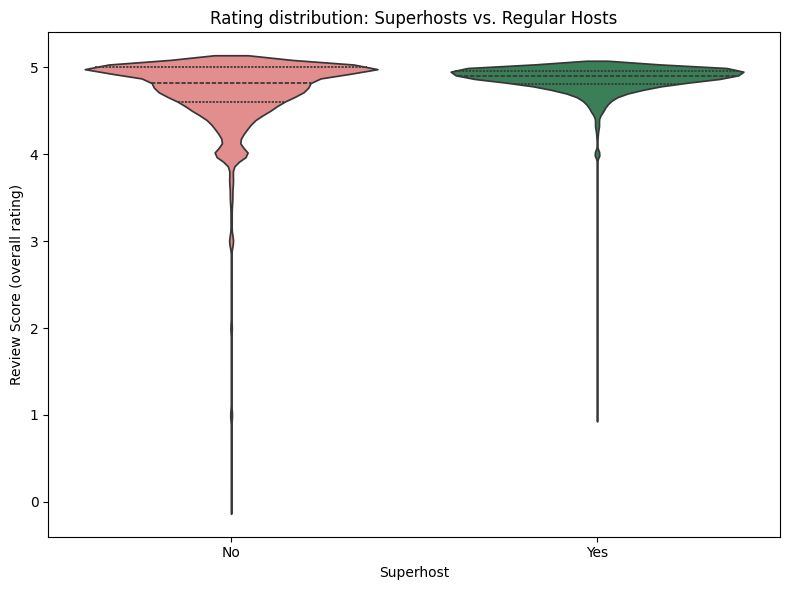

In [ ]:


os.makedirs("../Data/SelmasPlots", exist_ok=True)

# Filter out missing values
data = listings.dropna(subset=["host_is_superhost", "review_scores_rating"])

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=data,
    x="host_is_superhost",
    y="review_scores_rating",
    hue="host_is_superhost",
    palette={"t": "seagreen", "f": "lightcoral"},
    inner="quartile",   # shows median + quartiles inside the violin
    legend=False,
)
plt.xlabel("Superhost")
plt.ylabel("Review Score (overall rating)")
plt.title("Rating distribution: Superhosts vs. Regular Hosts")
plt.xticks([0, 1], ["No", "Yes"])
plt.tight_layout()
plt.savefig("../Data/SelmasPlots/violin_superhost_rating.png", bbox_inches="tight", dpi=150)
plt.show()

# Host tenure
-> How long is the host on AirBnB?

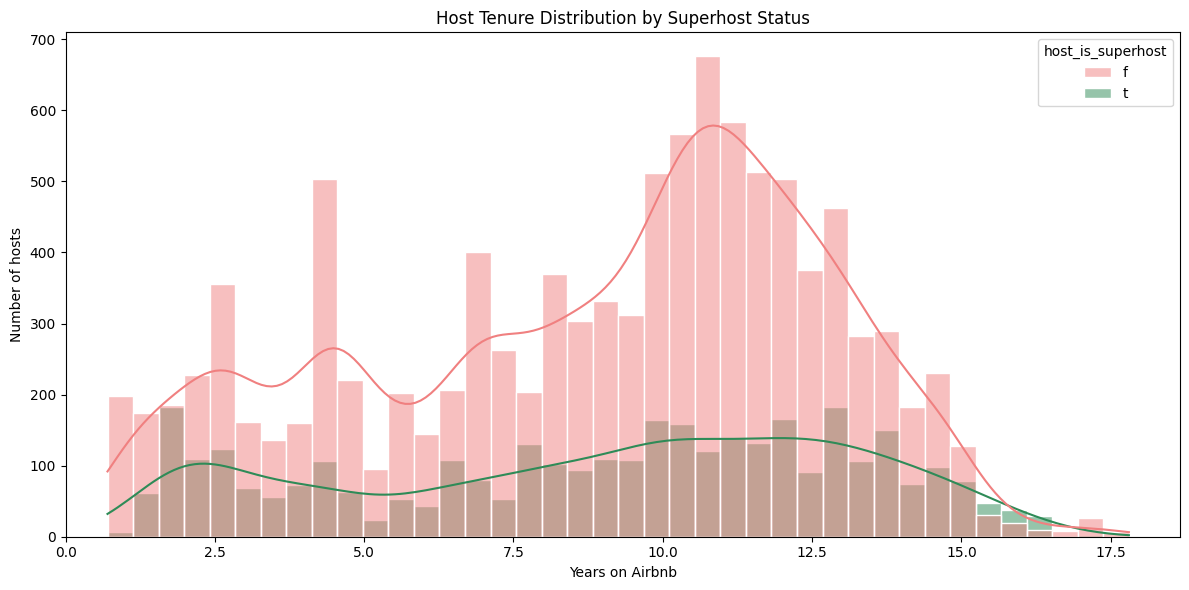

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

os.makedirs("../Data/SelmasPlots", exist_ok=True)

# Calculate tenure in years
listings["host_since"] = pd.to_datetime(listings["host_since"])
tenure_years = (pd.Timestamp("today") - listings["host_since"]).dt.days / 365.25

# Add tenure as a column for plotting
data = listings.assign(tenure=tenure_years).dropna(subset=["tenure", "host_is_superhost"])

# Histogram with KDE, split by superhost
plt.figure(figsize=(12, 6))
sns.histplot(
    data=data,
    x="tenure",
    hue="host_is_superhost",
    kde=True,
    bins=40,
    palette={"t": "seagreen", "f": "lightcoral"},
    edgecolor="white",
)
plt.xlabel("Years on Airbnb")
plt.ylabel("Number of hosts")
plt.title("Host Tenure Distribution by Superhost Status")
plt.xlim(left=0)
plt.tight_layout()
plt.savefig("../Data/SelmasPlots/host_tenure_superhost.png", bbox_inches="tight", dpi=150)
plt.show()

# Clustering


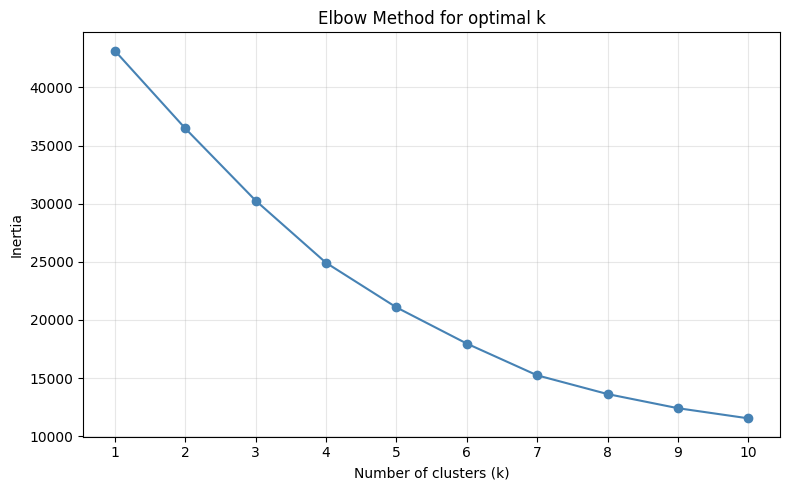

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os

os.makedirs("../Data/SelmasPlots", exist_ok=True)

features = [
    "price", "accommodates", "review_scores_rating",
    "availability_365", "calculated_host_listings_count",
    "number_of_reviews_ltm",
]
data = listings[features].dropna().copy()

# Force price conversion (replaces the old if-block)
data["price"] = (
    data["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

X = StandardScaler().fit_transform(data)

ks = range(1, 11)
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(ks, inertias, marker="o", color="steelblue")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for optimal k")
plt.xticks(ks)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Data/SelmasPlots/elbow_method.png", bbox_inches="tight", dpi=150)
plt.show()

In [13]:
from sklearn.metrics import silhouette_score

for k in [3, 4, 5, 6, 7]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    score = silhouette_score(X, km.labels_, sample_size=2000, random_state=42)
    print(f"k={k}: silhouette = {score:.3f}")

k=3: silhouette = 0.227
k=4: silhouette = 0.242
k=5: silhouette = 0.271
k=6: silhouette = 0.287
k=7: silhouette = 0.308


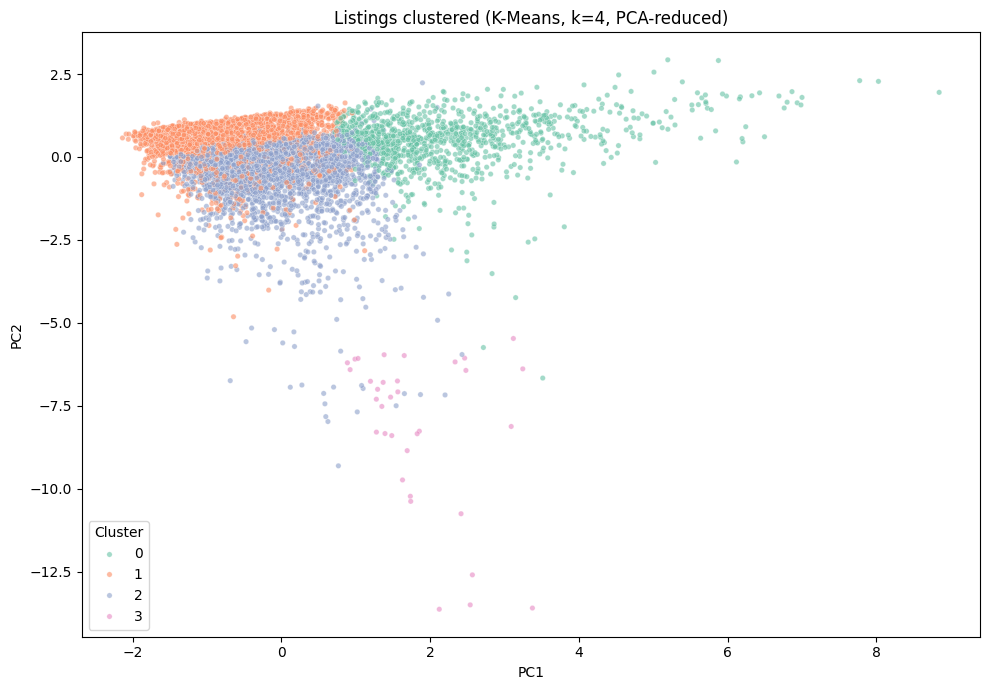


=== Cluster profiles (mean values) ===
         price  accommodates  review_scores_rating  availability_365  \
cluster                                                                
0        280.9           7.0                   4.7             237.3   
1        104.2           2.7                   4.8              79.3   
2        108.8           2.8                   4.7             298.5   
3        136.3           2.6                   4.1             162.9   

         calculated_host_listings_count  number_of_reviews_ltm  
cluster                                                         
0                                   9.5                   18.4  
1                                   4.2                   13.8  
2                                   7.6                   20.2  
3                                 311.0                    0.4  

=== Cluster sizes ===
cluster
0    1089
1    2789
2    3261
3      34
Name: count, dtype: int64


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../Data/SelmasPlots", exist_ok=True)

features = [
    "price", "accommodates", "review_scores_rating",
    "availability_365", "calculated_host_listings_count",
    "number_of_reviews_ltm",
]
data = listings[features].dropna().copy()

data["price"] = (
    data["price"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

data = data[data["price"] < 1000]   # filter unrealistic prices

X = StandardScaler().fit_transform(data)

# Cluster with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X)

# PCA for 2D visualization
pca = PCA(n_components=2)
coords = pca.fit_transform(X)
data["pc1"], data["pc2"] = coords[:, 0], coords[:, 1]

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=data, x="pc1", y="pc2", hue="cluster",
    palette="Set2", s=15, alpha=0.6,
)
plt.title("Listings clustered (K-Means, k=4, PCA-reduced)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("../Data/SelmasPlots/cluster_scatter_k4.png", bbox_inches="tight", dpi=150)
plt.show()

# Interpretation — cluster profiles
print("\n=== Cluster profiles (mean values) ===")
print(data.groupby("cluster")[features].mean().round(1))

print("\n=== Cluster sizes ===")
print(data["cluster"].value_counts().sort_index())

## Cluster Interpretation

**Cluster 0 — "Large Premium Apartments" (n=1,089, ~14%)**
- Expensive (€281/night), large (7 guests), well-rated (4.7)
- 9.5 listings per host → leans professional
- Available year-round (237 days)
- → **Luxury / family apartments, often run by professional providers**

**Cluster 1 — "Casual Private Hosts" (n=2,789, ~36%)**
- Cheap (€104), small (2.7 guests), best rating (4.8)
- Only 79 days available → classic **private apartment, rented occasionally**
- 4 listings per host (moderate activity)
- → **Berliners who rent out their place once in a while**

**Cluster 2 — "Active Standard Rentals" (n=3,261, ~42%)**
- Mid-price (€109), small (2.8 guests), good rating (4.7)
- Almost year-round availability (298 days) → **dedicated rental**
- 7.6 listings per host, many reviews (20)
- → **Semi-professional hosts, the "bread and butter" of Airbnb**

**Cluster 3 — "Mega Commercial Operators" (n=34, ~0.4%)**
- 311 listings per host (!) → **agencies / management companies**
- Worst rating (4.1) → mass operation
- Mid availability, hardly any reviews → despite scale, low booking activity per listing
- → **Industrial-scale rental companies**

---

## The Berlin Story

- **78% are private individuals or small providers** (Clusters 1 + 2)
- **14% are premium providers** (Cluster 0)
- **0.4% are mega-hosts** with 300+ listings per account
- Ratings decline as commercialization grows (4.8 → 4.1) — **private hosts get better reviews than corporates**

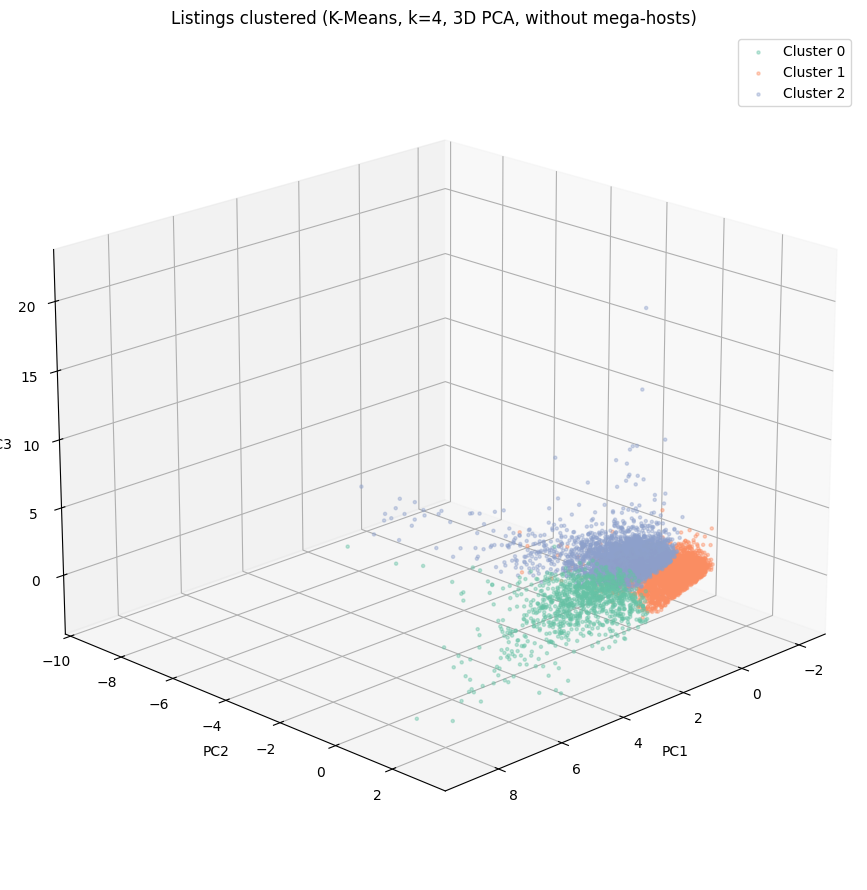

In [20]:
# clusters in 3d

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

os.makedirs("../Data/SelmasPlots", exist_ok=True)

features = [
    "price", "accommodates", "review_scores_rating",
    "availability_365", "calculated_host_listings_count",
    "number_of_reviews_ltm",
]
data = listings[features].dropna().copy()
data["price"] = (
    data["price"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
data = data[data["price"] < 1000]

X = StandardScaler().fit_transform(data)

# Cluster
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X)

# PCA with 3 components
pca = PCA(n_components=3)
coords = pca.fit_transform(X)
data["pc1"], data["pc2"], data["pc3"] = coords[:, 0], coords[:, 1], coords[:, 2]



# ... bis nach pca.fit_transform(X) ...

# NEU: vor dem Plot Outlier rausfiltern
data_plot = data[data["cluster"] != 3]

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

colors = {0: "#66c2a5", 1: "#fc8d62", 2: "#8da0cb", 3: "#e78ac3"}
for cluster_id in sorted(data_plot["cluster"].unique()):   # data_plot statt data
    subset = data_plot[data_plot["cluster"] == cluster_id]   # data_plot statt data
    ax.scatter(
        subset["pc1"], subset["pc2"], subset["pc3"],
        c=colors[cluster_id], label=f"Cluster {cluster_id}",
        s=5, alpha=0.4,   # kleinere Punkte
    )

ax.view_init(elev=20, azim=45)   # NEU: Blickwinkel

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Listings clustered (K-Means, k=4, 3D PCA, without mega-hosts)")
ax.legend()
plt.tight_layout()
plt.savefig("../Data/SelmasPlots/cluster_scatter_3d_clean.png", bbox_inches="tight", dpi=150)
plt.show()

# Price ↔ Rating → Scatter with regression line

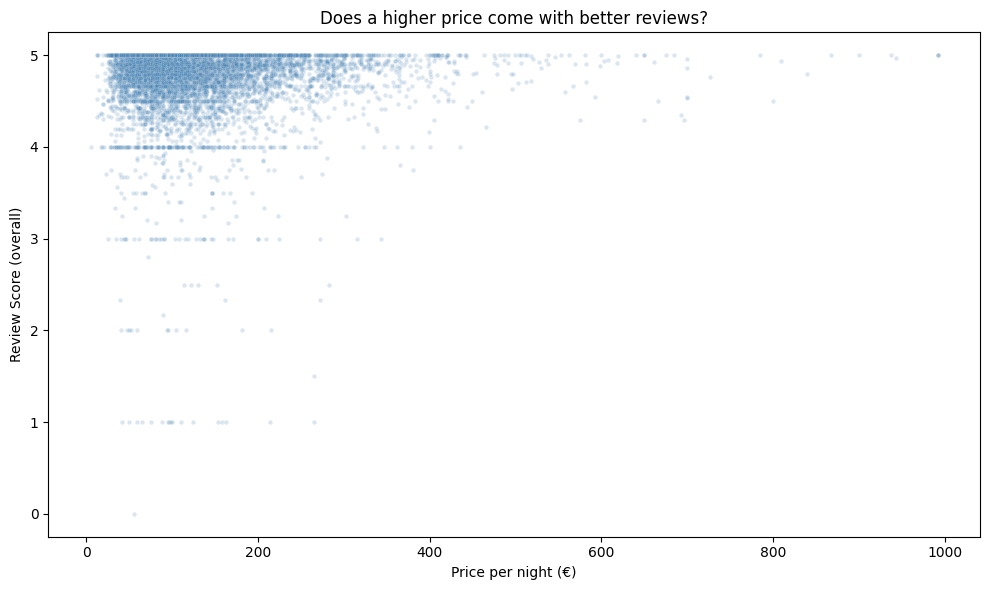

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs("../Data/SelmasPlots", exist_ok=True)

# Prepare data
data = listings[["price", "review_scores_rating"]].dropna().copy()
data["price"] = (
    data["price"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
data = data[data["price"] < 1000]  # remove outliers

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data, x="price", y="review_scores_rating",
    alpha=0.2, s=10, color="steelblue",
)
plt.xlabel("Price per night (€)")
plt.ylabel("Review Score (overall)")
plt.title("Does a higher price come with better reviews?")
plt.tight_layout()
plt.savefig("../Data/SelmasPlots/price_vs_rating.png", bbox_inches="tight", dpi=150)
plt.show()

not true: the better the rating the higher the price. therefore price != quality

# 90 day violation

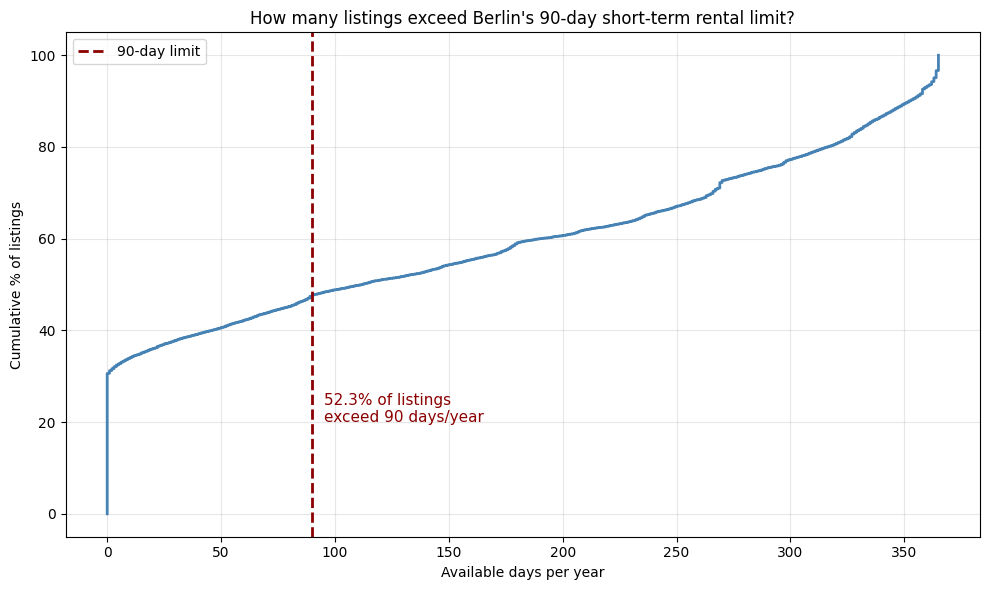

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("../Data/SelmasPlots", exist_ok=True)

avail = listings["availability_365"].dropna().sort_values().values
ecdf = np.arange(1, len(avail) + 1) / len(avail) * 100

plt.figure(figsize=(10, 6))
plt.plot(avail, ecdf, color="steelblue", linewidth=2)

# Berlin's 90-day rule: short-term rentals beyond 90 days/year typically require permits
plt.axvline(90, color="darkred", linestyle="--", linewidth=2, label="90-day limit")

# Find what % of listings are below the line
pct_below_90 = (avail <= 90).mean() * 100
plt.text(95, 20, f"{100 - pct_below_90:.1f}% of listings\nexceed 90 days/year",
         color="darkred", fontsize=11)

plt.xlabel("Available days per year")
plt.ylabel("Cumulative % of listings")
plt.title("How many listings exceed Berlin's 90-day short-term rental limit?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Data/SelmasPlots/availability_ecdf.png", bbox_inches="tight", dpi=150)
plt.show()